In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_fscore_support, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "datasets" / "dataset_limpio.xlsx"
RESULTS_PATH = BASE_DIR / "data" / "results" / "rachs1"
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_PATH)
print(f"Total registros: {len(df)}")

Total registros: 699


In [2]:
df_rachs = df[df['RACHS-1'] != 'NO APLICA'].copy()
df_rachs['RACHS-1'] = pd.to_numeric(df_rachs['RACHS-1'])

mapeo_mortalidad = {
    'no murio'                      : 0,
    'murió en los primeros 30 dias' : 1,
    'murió despues de 30 dias'      : 1   # ambas = "muere"
}
df_rachs['mortalidad_num'] = df_rachs['Mortalidad'].map(mapeo_mortalidad)

def rachs_to_clase(score):
    return 0 if score <= 3 else 1

df_rachs['rachs_pred'] = df_rachs['RACHS-1'].apply(rachs_to_clase)

y_real        = df_rachs['mortalidad_num'].astype(int)
y_pred_rachs  = df_rachs['rachs_pred'].astype(int)
# Score RACHS-1 normalizado [0-1] para ROC-AUC (mayor score = mayor riesgo)
y_score_rachs = (df_rachs['RACHS-1'] / 6.0).values

print(f"Registros con RACHS-1: {len(df_rachs)}")
print(f"Excluidos (NO APLICA): {len(df) - len(df_rachs)}")
print(f"\nMortalidad real:  {dict(y_real.value_counts().sort_index())}")
print(f"Pred RACHS-1:     {dict(pd.Series(y_pred_rachs).value_counts().sort_index())}")


Registros con RACHS-1: 576
Excluidos (NO APLICA): 123

Mortalidad real:  {0: np.int64(513), 1: np.int64(63)}
Pred RACHS-1:     {0: np.int64(494), 1: np.int64(82)}


In [3]:
print("=" * 70)
print("OVERALL METRICS - RACHS-1")
print("=" * 70)

overall_metrics = {
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)',
               'F1-Score (macro)', "Cohen's Kappa"],
    'RACHS-1': [
        f"{accuracy_score(y_real, y_pred_rachs):.4f}",
        f"{precision_score(y_real, y_pred_rachs, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_real, y_pred_rachs, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_real, y_pred_rachs, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_real, y_pred_rachs):.4f}",
    ]
}

df_overall = pd.DataFrame(overall_metrics)
print(df_overall.to_string(index=False))

OVERALL METRICS - RACHS-1
           Metric RACHS-1
         Accuracy  0.8767
Precision (macro)  0.6993
   Recall (macro)  0.7498
 F1-Score (macro)  0.7199
    Cohen's Kappa  0.4412


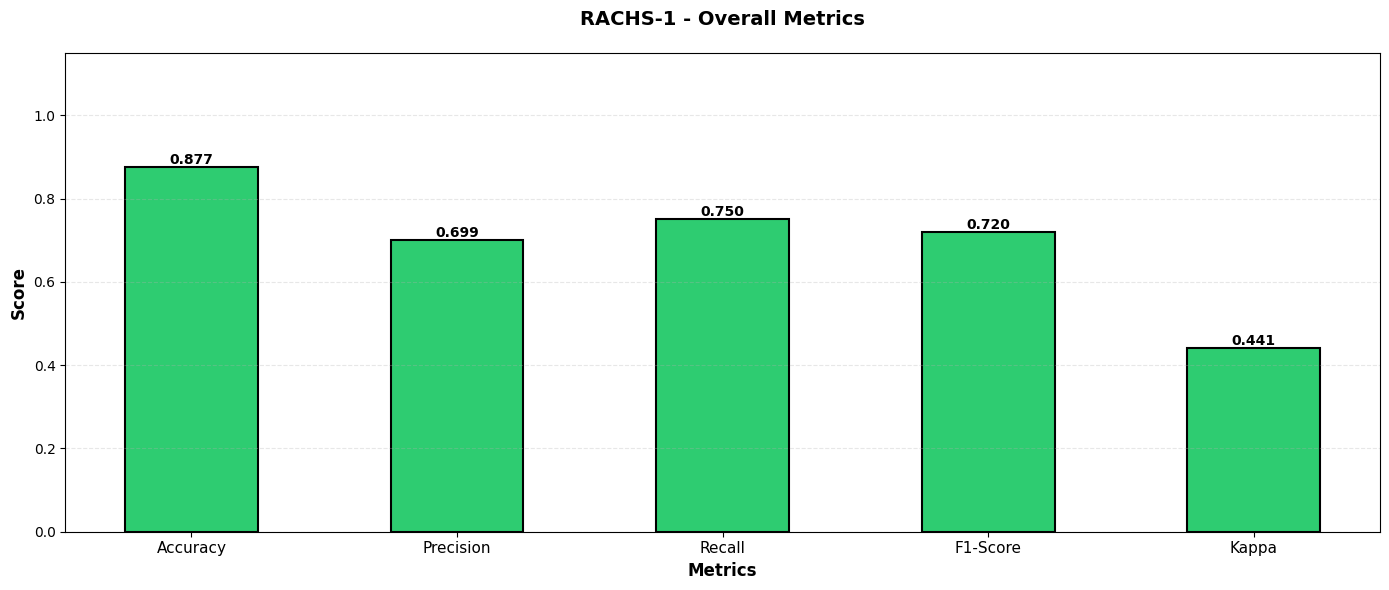

✓ Plot saved


In [4]:
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Kappa']
rachs_vals = [float(x) for x in df_overall['RACHS-1'].values]

x = np.arange(len(metrics_labels))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(x, rachs_vals, width=0.5, color='#2ecc71', edgecolor='black', linewidth=1.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('RACHS-1 - Overall Metrics', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.15])
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'overall_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved")


In [5]:
prec, rec, f1, sup = precision_recall_fscore_support(y_real, y_pred_rachs, average=None)
cm = confusion_matrix(y_real, y_pred_rachs)
sensitivity, specificity = [], []

for i in range(cm.shape[0]):
    tp = cm[i, i]; fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp; tn = cm.sum() - (tp + fn + fp)
    sensitivity.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

df_class = pd.DataFrame({
    'Class': [0, 1], 'Precision': prec, 'Recall': rec, 'F1-Score': f1,
    'Sensitivity': sensitivity, 'Specificity': specificity, 'Support': sup
})

print("=" * 70)
print("PER-CLASS METRICS - RACHS-1")
print("=" * 70)
print(df_class.to_string(index=False))


PER-CLASS METRICS - RACHS-1
 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0   0.947368 0.912281  0.929494     0.912281     0.587302      513
     1   0.451220 0.587302  0.510345     0.587302     0.912281       63


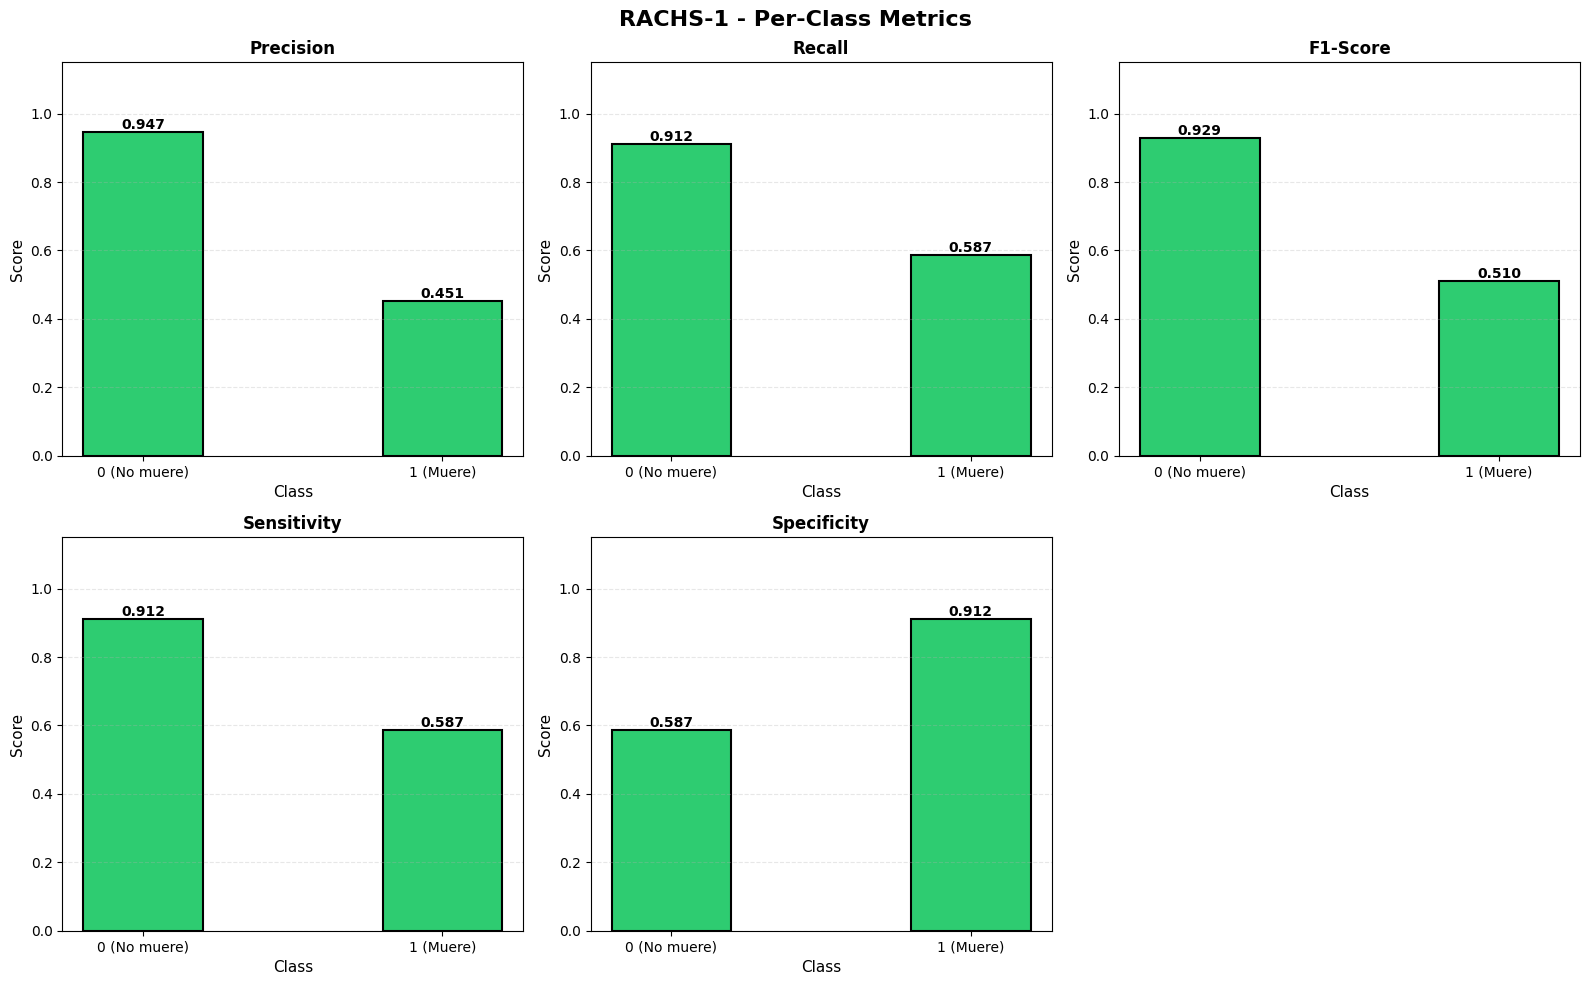

✓ Plot saved


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('RACHS-1 - Per-Class Metrics', fontsize=16, fontweight='bold')

data_map = {
    'Precision':   prec,
    'Recall':      rec,
    'F1-Score':    f1,
    'Sensitivity': sensitivity,
    'Specificity': specificity,
}

for idx, (metric, data) in enumerate(data_map.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    x = np.arange(2)
    bars = ax.bar(x, data, width=0.4, color='#2ecc71', edgecolor='black', linewidth=1.5)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(['0 (No muere)', '1 (Muere)'], fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.15])

axes[1, 2].remove()  # elimina el 6° subplot vacío
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'perclass_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved")


ROC-AUC SCORES (Binary)
RACHS-1 AUC: 0.8352


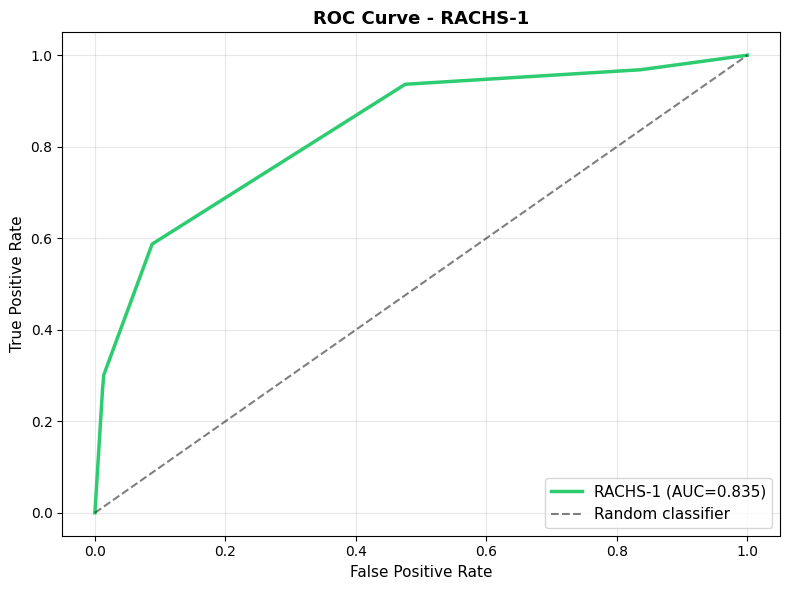

In [7]:
print("=" * 70)
print("ROC-AUC SCORES (Binary)")
print("=" * 70)

auc_rachs = roc_auc_score(y_real, y_score_rachs)
print(f"RACHS-1 AUC: {auc_rachs:.4f}")

fpr, tpr, _ = roc_curve(y_real, y_score_rachs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'RACHS-1 (AUC={auc_rachs:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - RACHS-1', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'roc_curve_rachs1.png', dpi=150, bbox_inches='tight')
plt.show()


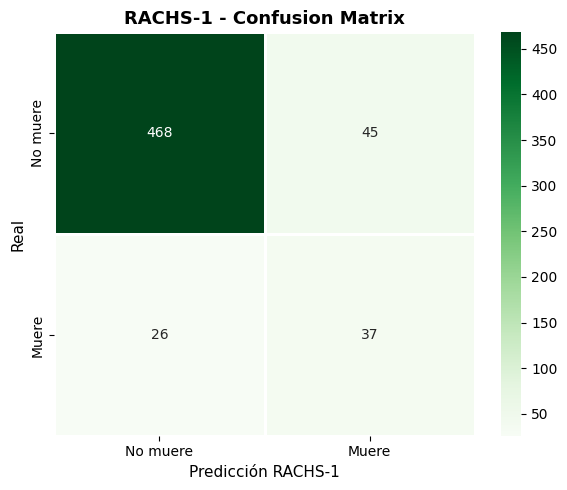

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['No muere', 'Muere'],
            yticklabels=['No muere', 'Muere'],
            linewidths=2)
ax.set_title('RACHS-1 - Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Real', fontsize=11)
ax.set_xlabel('Predicción RACHS-1', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'confusion_matrix_rachs1.png', dpi=150, bbox_inches='tight')
plt.show()
